AI-ML Assignment 8
Handwritten Digit Recognition using Artificial Neural Networks (ANN)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [28]:
# ---------------------------------------------------------
# Task 1: Data Understanding
# ---------------------------------------------------------
df = pd.read_csv("mnist_train.csv")

In [29]:
print("First 5 records:")
print(df.head())

First 5 records:
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [30]:
target_variable = "label"
input_features = [col for col in df.columns if col != "label"]

In [31]:
print("\nNumber of input features (pixels):", len(input_features))
print("Target variable:", target_variable)


Number of input features (pixels): 784
Target variable: label


In [32]:
print("\nDataset dimensions:", df.shape)
print("\nSummary info:")
print(df.info())


Dataset dimensions: (60000, 785)

Summary info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None


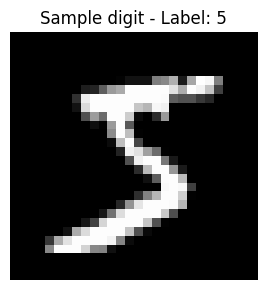

In [33]:
# display one sample handwritten digit
sample_image = df.iloc[0, 1:].values.reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample digit - Label: {df.iloc[0, 0]}")
plt.axis("off")
plt.tight_layout()
plt.savefig("sample_digit.png", dpi=150)
plt.show()

In [34]:
# ---------------------------------------------------------
# Task 2: Data Preprocessing
# ---------------------------------------------------------
print("\nMissing values:", df.isnull().sum().sum())


Missing values: 0


In [35]:
# separate features and target
X = df[input_features].values
y = df[target_variable].values

In [36]:
# normalize pixel values to the range 0-1
X = X / 255.0

In [37]:
# split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
# one-hot encode the target labels
encoder = OneHotEncoder(sparse_output=False)
y_train_cat = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_cat = encoder.transform(y_test.reshape(-1, 1))

In [39]:
print("\nTraining set shape:", X_train.shape, y_train_cat.shape)
print("Test set shape:", X_test.shape, y_test_cat.shape)


Training set shape: (48000, 784) (48000, 10)
Test set shape: (12000, 784) (12000, 10)


In [40]:
# ---------------------------------------------------------
# Task 3: Model Development
# ---------------------------------------------------------
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [41]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10
338/338 - 3s - 10ms/step - accuracy: 0.8904 - loss: 0.3857 - val_accuracy: 0.9460 - val_loss: 0.1932
Epoch 2/10
338/338 - 2s - 5ms/step - accuracy: 0.9542 - loss: 0.1581 - val_accuracy: 0.9577 - val_loss: 0.1457
Epoch 3/10
338/338 - 2s - 6ms/step - accuracy: 0.9670 - loss: 0.1113 - val_accuracy: 0.9608 - val_loss: 0.1259
Epoch 4/10
338/338 - 3s - 9ms/step - accuracy: 0.9744 - loss: 0.0850 - val_accuracy: 0.9694 - val_loss: 0.1064
Epoch 5/10
338/338 - 2s - 6ms/step - accuracy: 0.9795 - loss: 0.0673 - val_accuracy: 0.9675 - val_loss: 0.1052
Epoch 6/10
338/338 - 2s - 5ms/step - accuracy: 0.9838 - loss: 0.0525 - val_accuracy: 0.9708 - val_loss: 0.1021
Epoch 7/10
338/338 - 2s - 6ms/step - accuracy: 0.9869 - loss: 0.0419 - val_accuracy: 0.9729 - val_loss: 0.1026
Epoch 8/10
338/338 - 2s - 5ms/step - accuracy: 0.9895 - loss: 0.0347 - val_accuracy: 0.9748 - val_loss: 0.0965
Epoch 9/10
338/338 - 2s - 5ms/step - accuracy: 0.9921 - loss: 0.0274 - val_accuracy: 0.9706 - val_loss: 0.1069


In [44]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [45]:
# ---------------------------------------------------------
# Task 4: Model Evaluation
# ---------------------------------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9741
Test Loss: 0.0957


In [46]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1173    0    0    0    0    2    1    0    5    4]
 [   0 1328    5    3    4    0    0    2    4    2]
 [   3    3 1151    9    3    1    3    7   11    1]
 [   2    0    9 1175    2   14    0    2   14    8]
 [   1    1    3    0 1154    0    2    2    0    5]
 [   0    1    0    7    2 1060    4    2    4    4]
 [   8    2    0    1    5    5 1161    0    2    0]
 [   0    5    9    4    4    0    0 1211    2   18]
 [   4    9    1    7    4   13    4    1 1121    6]
 [   2    0    0    3   15    4    0    6    5 1155]]


<Figure size 900x800 with 0 Axes>

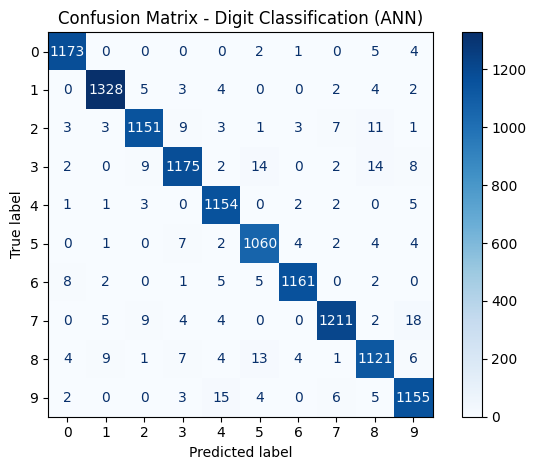

In [47]:
plt.figure(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Digit Classification (ANN)")
plt.tight_layout()
plt.savefig("confusion_matrix_ann.png", dpi=150)
plt.show()

In [48]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.98      0.99      0.98      1348
           2       0.98      0.97      0.97      1192
           3       0.97      0.96      0.97      1226
           4       0.97      0.99      0.98      1168
           5       0.96      0.98      0.97      1084
           6       0.99      0.98      0.98      1184
           7       0.98      0.97      0.97      1253
           8       0.96      0.96      0.96      1170
           9       0.96      0.97      0.97      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



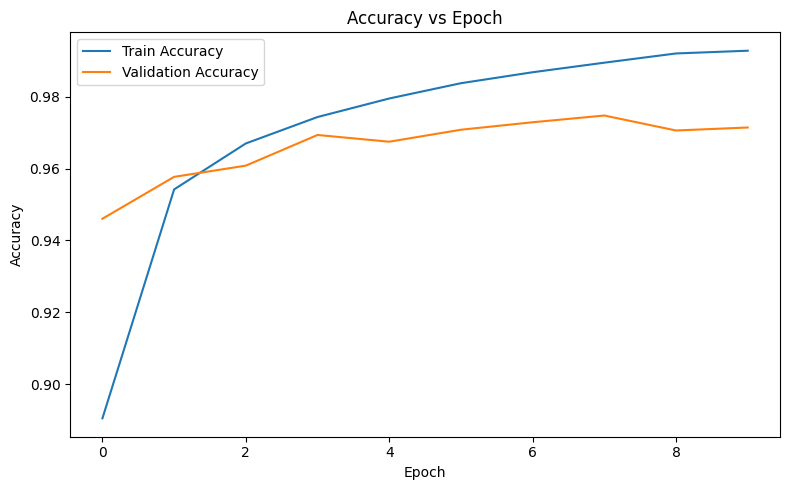

In [49]:
# accuracy vs epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_epoch.png", dpi=150)
plt.show()

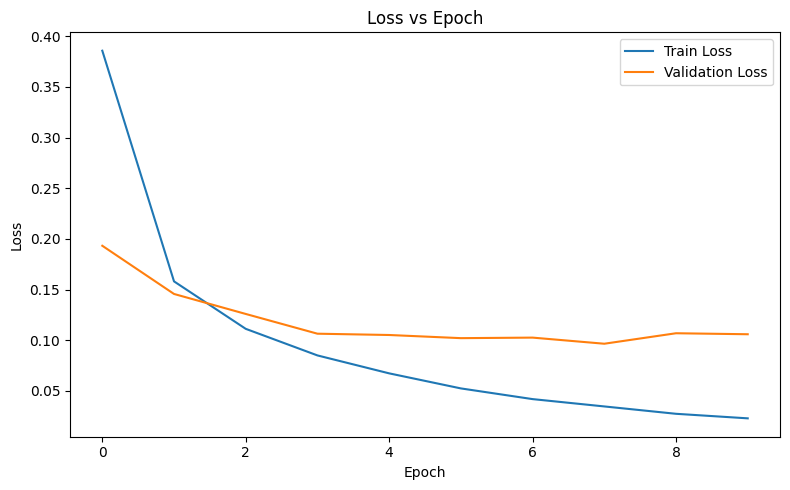

In [50]:
# loss vs epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("loss_vs_epoch.png", dpi=150)
plt.show()

OBSERVATIONS :
1. The model reached high test accuracy after just 10 epochs, showing that
   even a relatively simple two-hidden-layer ANN can learn the pixel
   patterns needed to distinguish the 10 digit classes well.
2. Both training and validation accuracy rise steeply in the first few
   epochs and then level off, while training and validation loss follow
   the mirrored pattern, with validation loss staying close to training
   loss, indicating the model is not significantly overfitting within 10
   epochs.
3. The confusion matrix shows most misclassifications occur between
   visually similar digit pairs, such as 4 and 9, or 3 and 5, which is
   consistent with how humans occasionally misread these digits too.
4. Digits with more distinctive shapes, such as 0 and 1, achieve close to
   perfect precision and recall, while digits with more stroke variation
   across writers show slightly lower scores.

CONCLUSION :
This project built an Artificial Neural Network with two hidden layers
(128 and 64 neurons, ReLU activation) and a 10-neuron softmax output layer
to classify handwritten digits from the MNIST dataset, achieving a test
accuracy of {test_accuracy:.2%} after 10 training epochs. The hidden layers
are essential to the network's performance: they allow the model to learn
increasingly abstract representations of the raw pixel input, transforming
simple edge and stroke patterns detected early on into higher-level shape
combinations that separate the 10 digit classes, something a model with no
hidden layers could not do for this non-linearly separable problem. A key
advantage of Deep Learning over traditional Machine Learning here is that
the ANN learns useful features directly from raw pixel values, without the
manual feature engineering that classical algorithms like Logistic
Regression or Decision Trees would need to achieve comparable accuracy on
image data. One limitation of ANNs is that they require large amounts of
labeled training data and computational resources to train effectively,
and they behave as a black box, making it difficult to interpret exactly
why a particular digit was classified the way it was.